In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve,auc, classification_report, confusion_matrix, accuracy_score
from scipy.stats import chi2_contingency
from imblearn.over_sampling import SMOTE

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/lung_cancer_dataset.csv')
df = pd.DataFrame(dataset)
df.info()
df.head ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
# Data Exploration
print("\n=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())


=== Dataset Overview ===
Shape: (309, 16)

First 5 rows:
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1         2         1         2                  2         2   
1                2         2         2         1                  1         1   
2                1         2         1         2                  1         2   
3                1         1         1         1                  2         1   
4                1         1         1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN 

In [ ]:
# Data Preprocessing
# Clean column names that is removing extra spaces
df.columns = df.columns.str.strip()

# Encode the target variable
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

# Encode categorical variables (GENDER)
df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})


In [ ]:
# Exploratory Data Analysis
print("\n=== Descriptive Statistics ===")
print(df.describe())


=== Descriptive Statistics ===
           GENDER         AGE     SMOKING  YELLOW_FINGERS     ANXIETY  \
count  309.000000  309.000000  309.000000      309.000000  309.000000   
mean     0.524272   62.673139    1.563107        1.569579    1.498382   
std      0.500221    8.210301    0.496806        0.495938    0.500808   
min      0.000000   21.000000    1.000000        1.000000    1.000000   
25%      0.000000   57.000000    1.000000        1.000000    1.000000   
50%      1.000000   62.000000    2.000000        2.000000    1.000000   
75%      1.000000   69.000000    2.000000        2.000000    2.000000   
max      1.000000   87.000000    2.000000        2.000000    2.000000   

       PEER_PRESSURE  CHRONIC DISEASE     FATIGUE     ALLERGY    WHEEZING  \
count     309.000000       309.000000  309.000000  309.000000  309.000000   
mean        1.501618         1.504854    1.673139    1.556634    1.556634   
std         0.500808         0.500787    0.469827    0.497588    0.497588   
mi

In [ ]:
mean_AGE = df['AGE'].mean()
print("mean of age is" + str(mean_AGE))
median_AGE = df['AGE'].median()
print (median_AGE)
mode_AGE = df['AGE'].mode()
print (mode_AGE)
min_AGE = df['AGE'].min()
print (min_AGE)
max_AGE = df['AGE'].max()
print (max_AGE)
std_dev_AGE = df['AGE'].std()
print(std_dev_AGE)

mean of age is62.67313915857605
62.0
0    64
Name: AGE, dtype: int64
21
87
8.210301387885993


In [ ]:
categorical_Data = ['GENDER', 'YELLOW_FINGERS', 'ANXIETY' , 'PEER_PRESSURE', 'LUNG_CANCER', 'CHRONIC DISEASE',  'WHEEZING', 'COUGHING']
categorical_Statistics = {col: df[col].value_counts() for col in categorical_Data}
# mode_vals = {col: df[col].mode()[0] for col in categorical_Data}
for col, statistics in categorical_Statistics.items():
    print (f" {col} Value Counts:\n" , statistics)
    # print (f" {col} Mode Value: {mode_vals[col]}\n")

 GENDER Value Counts:
 GENDER
1    162
0    147
Name: count, dtype: int64
 YELLOW_FINGERS Value Counts:
 YELLOW_FINGERS
2    176
1    133
Name: count, dtype: int64
 ANXIETY Value Counts:
 ANXIETY
1    155
2    154
Name: count, dtype: int64
 PEER_PRESSURE Value Counts:
 PEER_PRESSURE
2    155
1    154
Name: count, dtype: int64
 LUNG_CANCER Value Counts:
 LUNG_CANCER
1    270
0     39
Name: count, dtype: int64
 CHRONIC DISEASE Value Counts:
 CHRONIC DISEASE
2    156
1    153
Name: count, dtype: int64
 WHEEZING Value Counts:
 WHEEZING
2    172
1    137
Name: count, dtype: int64
 COUGHING Value Counts:
 COUGHING
2    179
1    130
Name: count, dtype: int64


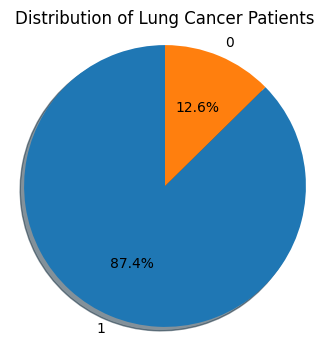

In [ ]:
#plotting the pie chart for distribution and  proporation of patients
counts = df['LUNG_CANCER'].value_counts()
labels = counts.index
sizes = counts.values
explode = [0.1] + [0] * (len(labels) - 1)
plt.figure(figsize=(4, 4))
plt.pie(sizes, labels= labels, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title ('Distribution of Lung Cancer Patients')
plt.axis ('equal')
plt.show()

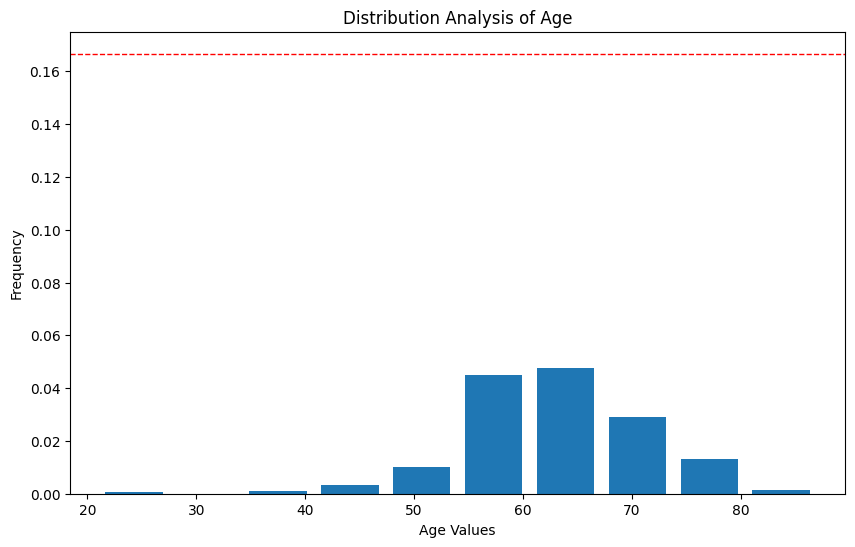

In [ ]:
# Age Distribution by Lung Cancer Status
plt.figure(figsize=(10, 6))
plt.hist(df['AGE'], bins= 10, density=True, rwidth=0.8)
plt.axhline(y=1/6, color='r', linestyle='dashed', linewidth=1)
plt.title('Distribution Analysis of Age')
plt.xlabel('Age Values')
plt.ylabel('Frequency')
plt.show()

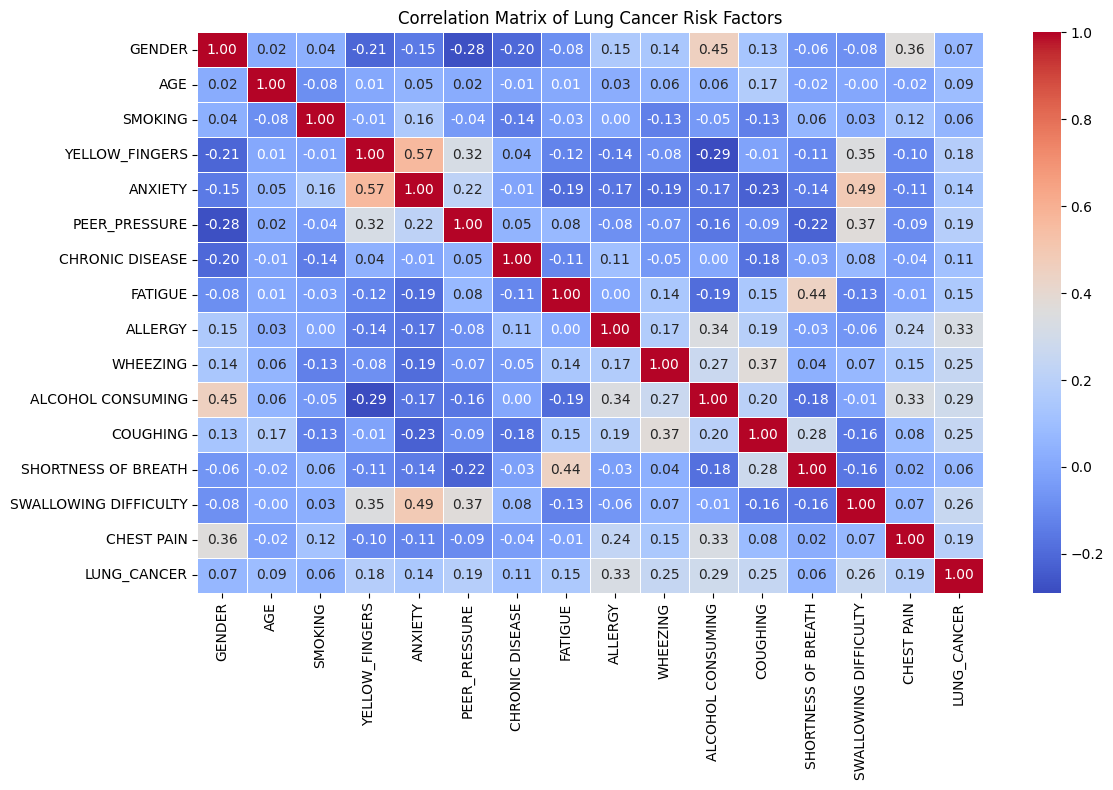

In [ ]:
# Correlation Analysis
# Calculate correlations
corr_matrix = df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Lung Cancer Risk Factors')
plt.tight_layout()
plt.show()


In [ ]:
# Get top 5 features related with LC
correlations = corr_matrix['LUNG_CANCER'].abs().sort_values(ascending=False)
top_5_corr_features = correlations[1:6]  # Skip LUNG_CANCER itself
print("\nTop 5 Features Correlated with LUNG_CANCER:")
print(top_5_corr_features)


Top 5 Features Correlated with LUNG_CANCER:
ALLERGY                  0.327766
ALCOHOL CONSUMING        0.288533
SWALLOWING DIFFICULTY    0.259730
WHEEZING                 0.249300
COUGHING                 0.248570
Name: LUNG_CANCER, dtype: float64


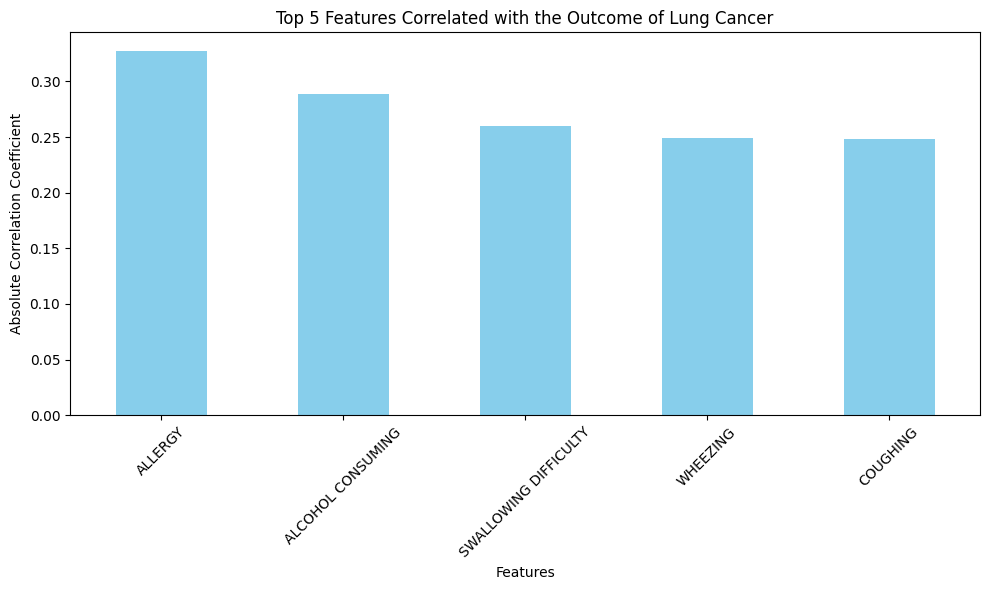

In [ ]:
# Feature Analysis Visualization
plt.figure(figsize=(10, 6))
top_5_corr_features.plot(kind='bar', color='skyblue')
plt.title('Top 5 Features Correlated with the Outcome of Lung Cancer')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation Coefficient')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Statistical Testing
# Chi-square tests for categorical variables
categorical_variables= ['SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE',
                   'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
                   'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
                   'SWALLOWING DIFFICULTY', 'CHEST PAIN']

print("\n=== Chi-square Test Results ===")
for var in categorical_variables:
    contingency_table = pd.crosstab(df[var], df['LUNG_CANCER'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #print(f"{var}: chi2 = {chi2:.2f}, p-value = {p:.4f}")
    print (var, chi2, p)


=== Chi-square Test Results ===
SMOKING 0.7225127713920805 0.39532090950779786
YELLOW_FINGERS 9.088186347643585 0.002572658676763601
ANXIETY 5.648389862825349 0.017471407296847576
PEER_PRESSURE 9.641594077965042 0.0019022008188155214
CHRONIC DISEASE 3.161200249878604 0.07540772311205218
FATIGUE 6.081100453795381 0.013663563031648557
ALLERGY 31.23895161132366 2.2814219222692283e-08
WHEEZING 17.723096047208042 2.5550549669090444e-05
ALCOHOL CONSUMING 24.00540608990681 9.60655896246563e-07
COUGHING 17.606121643361654 2.7171229854925574e-05
SHORTNESS OF BREATH 0.7906043281043282 0.3739174525027509
SWALLOWING DIFFICULTY 19.307277366241834 1.1128140435532809e-05
CHEST PAIN 10.083197505756283 0.0014962745817816542


In [ ]:
# T-test for continuous variable (AGE)
print(" T-test for AGE")
age_yes = df[df['LUNG_CANCER'] == 1]['AGE']
age_no = df[df['LUNG_CANCER'] == 0]['AGE']
t_stat, p_value = stats.ttest_ind(age_yes, age_no)
print(f"T-test for AGE: t = {t_stat}, p-value = {p_value}")

 T-test for AGE
T-test for AGE: t = 1.5738571666282906, p-value = 0.11655042930464404


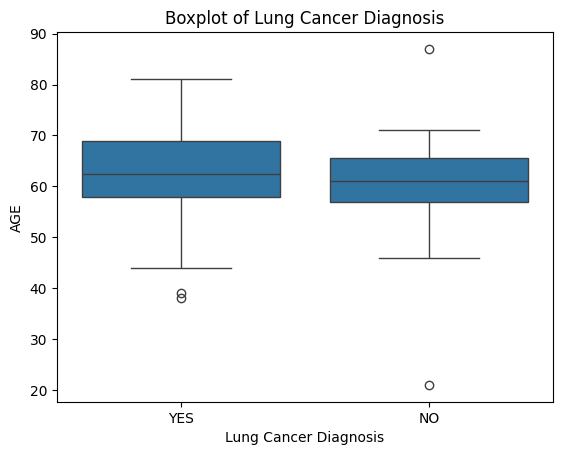

In [ ]:
# Data Visualization
# Boxplot of Age by Lung Cancer Status
#plotting boxplot
plot = dataset.boxplot
# to_plot = ['AGE']

plt.figure()
# for i, feature in enumerate(to_plot, 1):
# plt.subplot(2,2,i)
sns.boxplot(x= dataset['LUNG_CANCER'], y= dataset['AGE'])
plt.title("Boxplot of Lung Cancer Diagnosis")
plt.xlabel("Lung Cancer Diagnosis")
plt.ylabel("AGE")
plt.show()

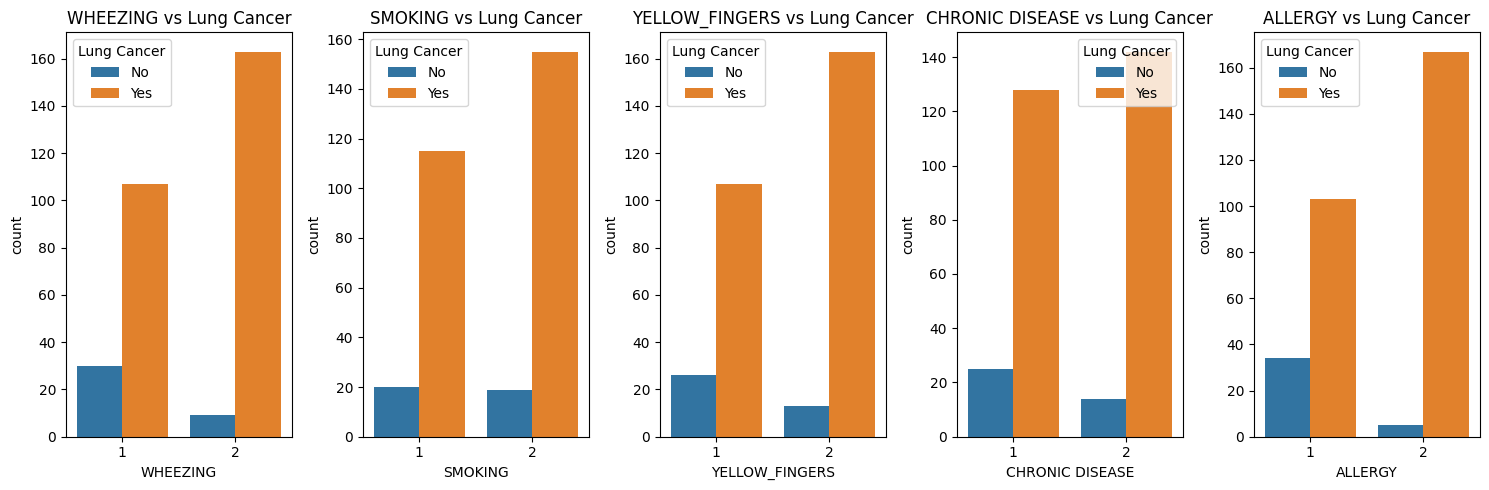

In [ ]:
# Count plots for categorical features
top_categorical = ['WHEEZING', 'SMOKING', 'YELLOW_FINGERS', 'CHRONIC DISEASE', 'ALLERGY']
plt.figure(figsize=(15, 5))
for i, var in enumerate(top_categorical, 1):
    plt.subplot(1, 5, i)
    sns.countplot(x=var, hue='LUNG_CANCER', data=df)
    plt.title(f'{var} vs Lung Cancer')
    plt.legend(title='Lung Cancer', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

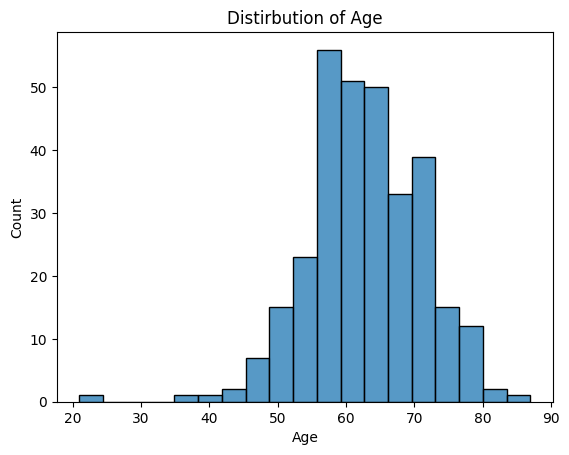

In [ ]:
sns.histplot (df['AGE'])
plt.xlabel ('Age')
plt.title ('Distirbution of Age')
plt.show()

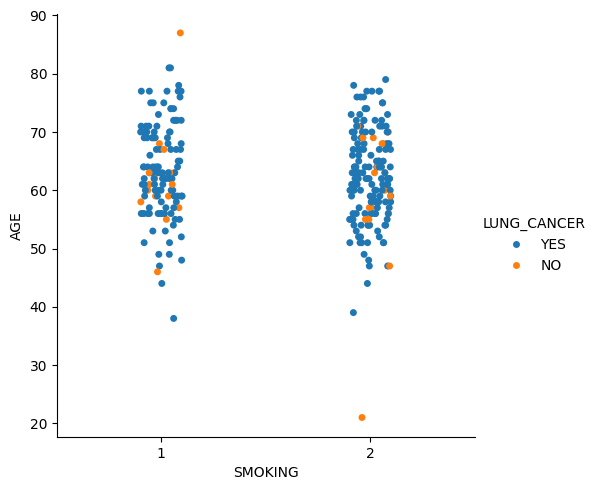

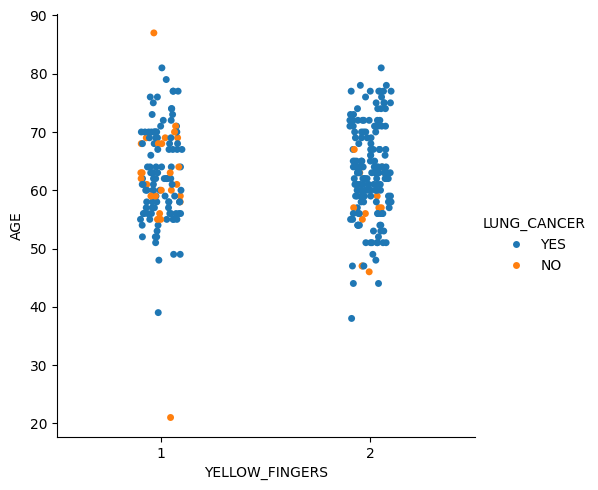

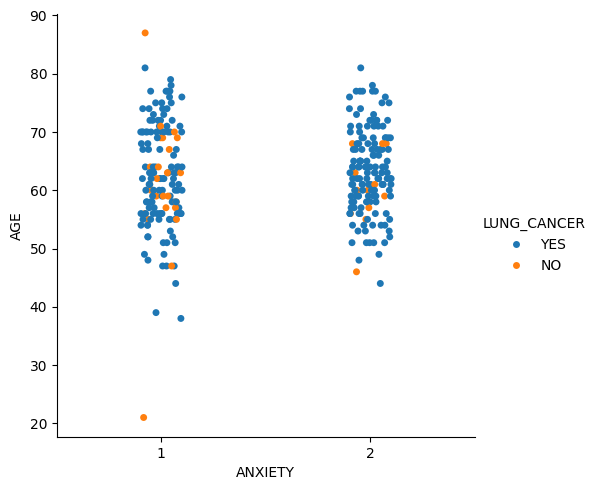

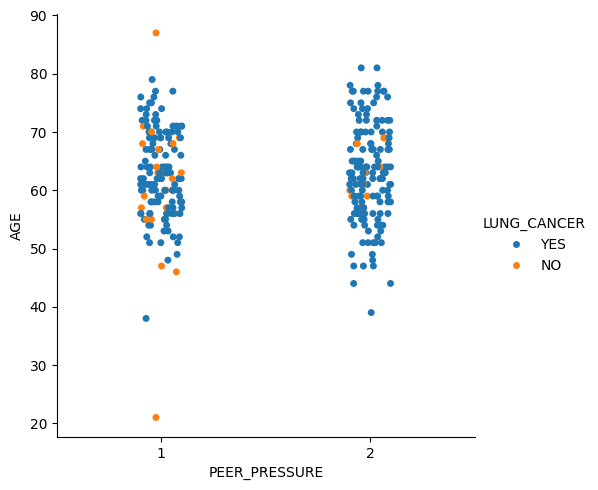

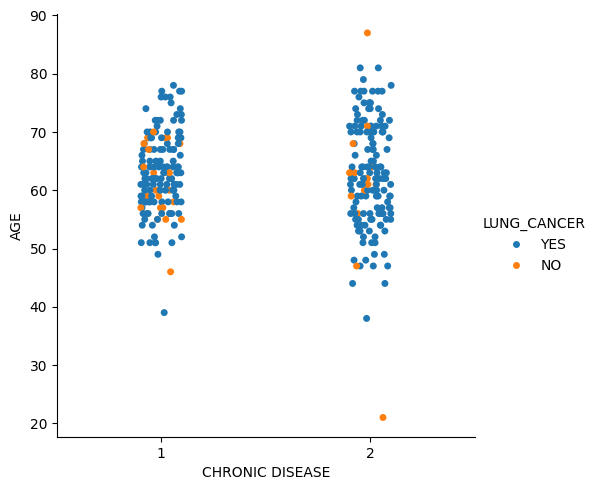

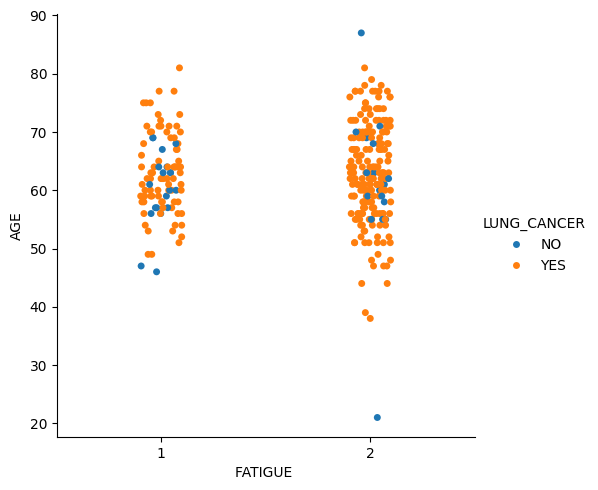

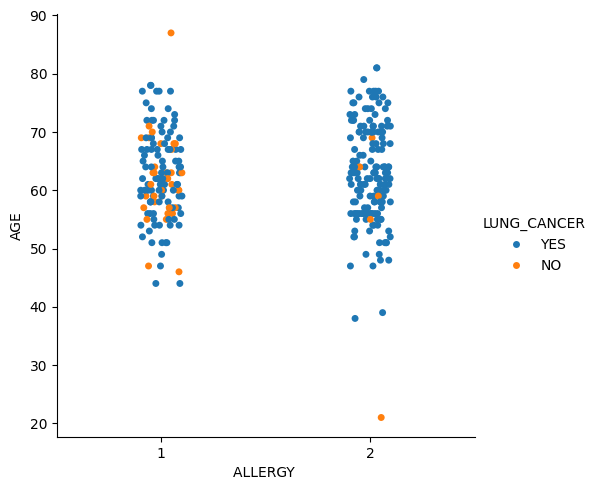

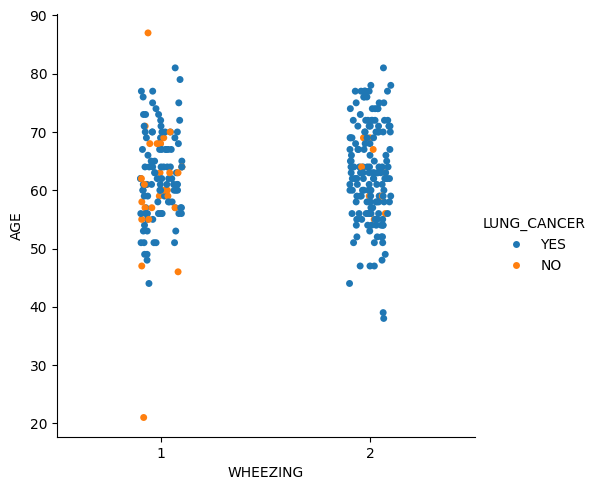

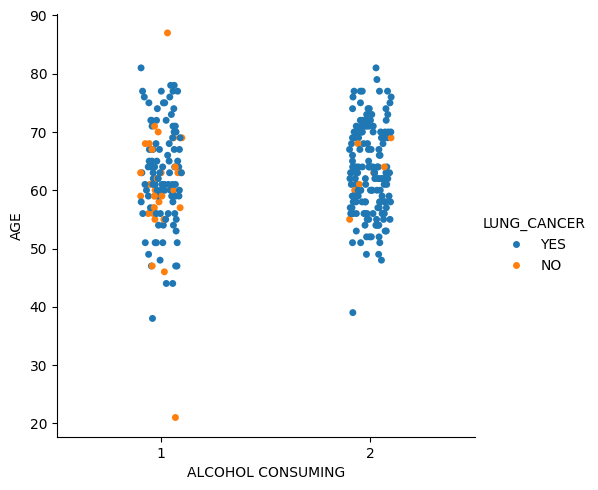

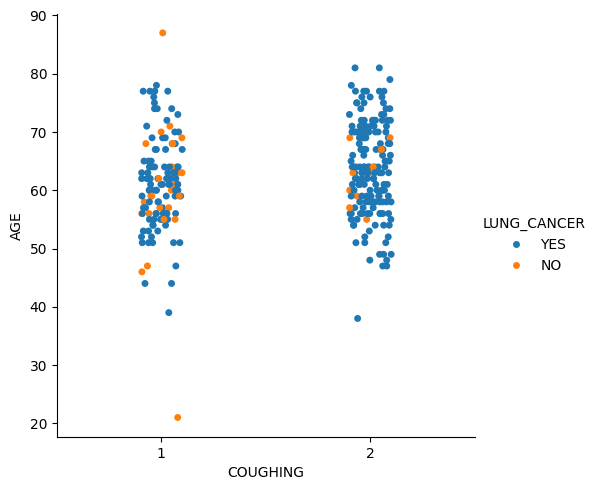

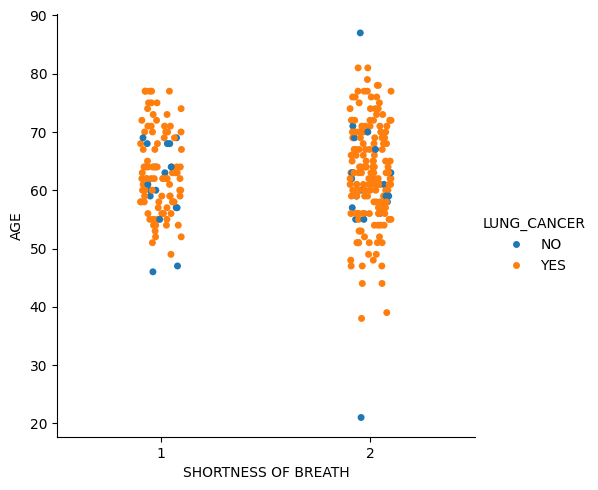

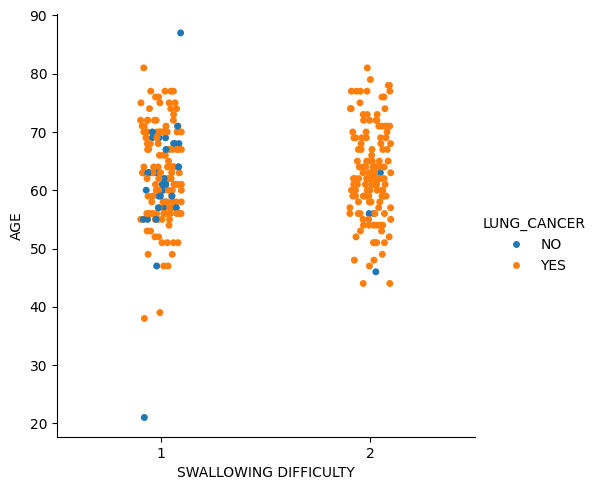

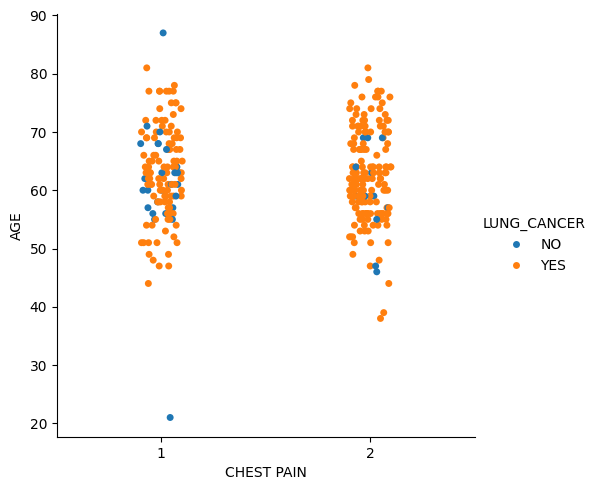

In [ ]:
#scatterplot

features = dataset.columns[2:-1]
# fig, ax = plt.subplots(4,4, figsize=(16,9))
for i, feature in enumerate(features, 1):
  sns.catplot(
      x = feature ,
      y= 'AGE' ,
      hue= 'LUNG_CANCER',
      data=dataset )

In [ ]:
# Statistical Modeling
# Prepare data for modeling
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train)
X_test_ss = scaler.transform(X_test)

In [ ]:
#applying smote for class imbalances
smote = SMOTE(random_state= 42)
X_train_reset, y_train_reset = smote.fit_resample(X_train_ss, y_train)

In [ ]:
pd.Series(y_train_reset).value_counts()
print("class distribution after smote", pd.Series(y_train_reset).value_counts())

class distribution after smote LUNG_CANCER
1    184
0    184
Name: count, dtype: int64


In [ ]:
model = LogisticRegression ()
model.fit (X_train_reset, y_train_reset)

LogisticRegression()

In [ ]:
y_test

,LUNG_CANCER
288,1
9,1
57,1
60,1
25,1
...,...
172,1
250,1
19,0
146,1


In [ ]:
y_test = list(np.array(y_test))

In [ ]:
y_pred = model.predict (X_test_ss)
#y_pred_probabablity = model.predict_proba(X_test_ss)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
classification_report = classification_report (y_test, y_pred)
print ("Accuracy is:", accuracy)
print ("Confusion Matrix is:", cm)
print ("classification report is:", classification_report)

Accuracy is: 0.9139784946236559
Confusion Matrix is: [[ 5  2]
 [ 6 80]]
classification report is:               precision    recall  f1-score   support

           0       0.45      0.71      0.56         7
           1       0.98      0.93      0.95        86

    accuracy                           0.91        93
   macro avg       0.72      0.82      0.75        93
weighted avg       0.94      0.91      0.92        93



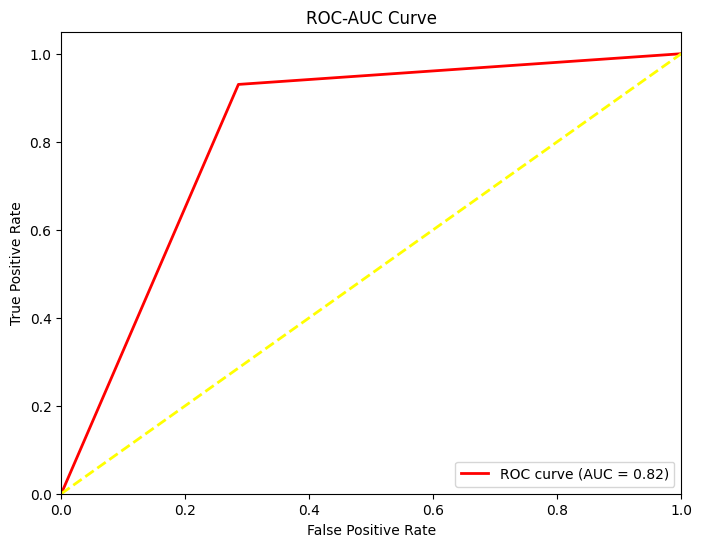

In [ ]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Calculate AUC
auc_curve = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='yellow', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc="lower right")
plt.show()